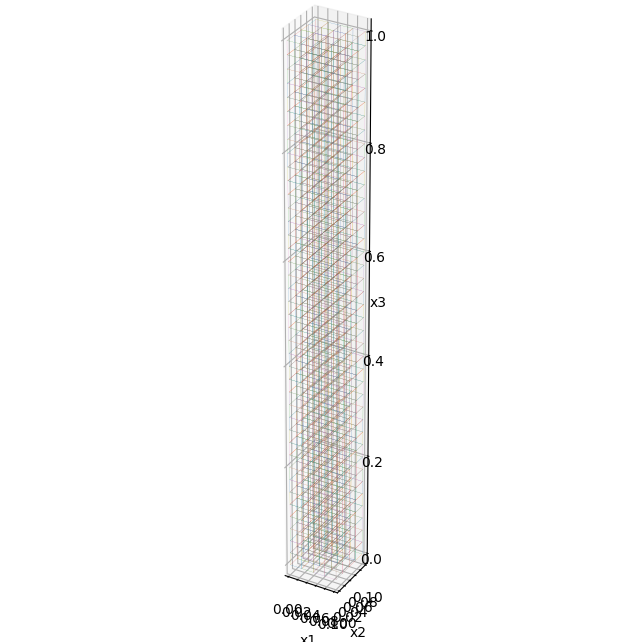

In [1]:
#mesh
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

plt.ion()  # enable interactive mode

points = np.loadtxt("points.txt")
hexas = np.loadtxt("hexas.txt", dtype=int)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

hex_edges = [
    (0,1),(1,2),(2,3),(3,0),
    (4,5),(5,6),(6,7),(7,4),
    (0,4),(1,5),(2,6),(3,7)
]

for elem in hexas:
    for edge in hex_edges:
        p1 = points[elem[edge[0]]]
        p2 = points[elem[edge[1]]]

        ax.plot([p1[0],p2[0]],
                [p1[1],p2[1]],
                [p1[2],p2[2]],
                linewidth=0.1)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")

ax.set_box_aspect([0.1,0.1,1])  # better for your beam

plt.show()

In [1]:
%matplotlib widget

IntSlider(value=0, description='Time Step', max=12)

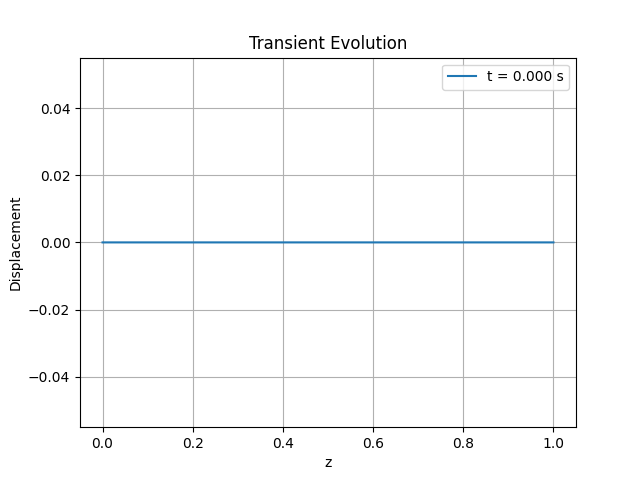

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import ipywidgets as widgets
from IPython.display import display

dt = 0.01  # <-- your timestep size

# -------------------------
# Load data
# -------------------------
points = np.loadtxt("points.txt")
z = points[:, 2]

solution_files = sorted(
    glob.glob("solutions/solution_*.txt"),
    key=lambda x: int(x.split("_")[-1].split(".")[0])
)

displacements = [np.loadtxt(f) for f in solution_files]
uz_all = [disp[:,1] for disp in displacements]

sorted_indices = np.argsort(z)
z_sorted = z[sorted_indices]
uz_all_sorted = [uz[sorted_indices] for uz in uz_all]

# -------------------------
# Plot Setup
# -------------------------
fig, ax = plt.subplots()

line, = ax.plot(z_sorted, uz_all_sorted[0], 
                label=f"t = {0*dt:.3f} s")

ax.set_xlabel("z")
ax.set_ylabel("Displacement")
ax.set_title("Transient Evolution")
ax.grid(True)
ax.legend()

# -------------------------
# Slider
# -------------------------
slider = widgets.IntSlider(
    min=0,
    max=len(uz_all_sorted)-1,
    step=1,
    value=0,
    description="Time Step"
)

def update(change):
    t = change["new"]
    line.set_ydata(uz_all_sorted[t])
    
    # Update legend label
    line.set_label(f"t = {t*dt:.3f} s")
    ax.legend()
    
    fig.canvas.draw_idle()

slider.observe(update, names='value')

display(slider)